# Detecção de Fraude em Transações de Clientes

**Autora:** Karen Pessoa  
**Data:** 27/02/2026  

## Projeto: Modelagem Preditiva de Fraude em Ambiente Desbalanceado

Este projeto tem como objetivo desenvolver e avaliar modelos de machine learning para detecção de fraude em transações financeiras online, utilizando o dataset público *IEEE-CIS Fraud Detection* (Kaggle). 

O conjunto de dados reúne informações transacionais e comportamentais associadas a operações de e-commerce, incluindo valor da transação, características de cartão, domínio de e-mail, variáveis temporias e atributos derivados de identidade, além da variável binária `isFraud`, que indica se a transação foi classificada como fraudulenta.

A detecção de fraude constitui um problema clássico na classificação binária com forte desbalanceamento de classes, em que eventos fraudulentos representam pequena fração do total de transações. Neste contexto, a modelagem exige não apenas boa capacidade discriminativa, mas também análise criteriosa do trade-off entre sensibilidade (recall) e precisão (precision), considerando os impactos operacionais de falsos positivos e falsos negativos.

Clique aqui para aceder à documentação detalhada do projeto [(README)](README.ipynb) e ao repositório completo no GitHub.

### Problem Framing & Data Acquisition

A fraude financeira consiste na realização de transações não autorizadas com o objetivo de obtenção indevida de recursos. 

Em ambiente de e-commerce, embora represente uma pequena fração do volume total de operações, seu impacto econômico é desproporcional: poucos eventos podem concentrar perdas financeiras relevantes, além de gerar custos operacionais e riscos reputacionais para a instituição. 

Esse cenário configura um típico problema de evento raro, marcado por forte desbalanceamento de classes. A mioria das transações é legítmica, enquanto a classe fraudulenta é minoria. Esse desequilíbrio impõe desafios técnicos à modelagem preditiva, uma vez que métricas tradicionais como acurácia tornam-se pouco informativas. 

Assim, a avaliação do modelo deve priorizar métricas alinhadas ao risco, como recall, precision, F1-score e AUC, bem como a análise do trade-off entre falsos positivos e falsos negativos.

A pergunta central que orienta esta análise é:

É possível construir um modelo capaz de identificar transações fraudulentas de forma consistente, equilibrando sensibilidade à fraude e impacto operacional?

In [71]:
# Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [58]:
# configuração credenciais kaggle
import os, json

# Carrega o kaggle.json que está na MESMA pasta do notebook
with open("kaggle.json", "r") as f:
    creds = json.load(f)

print("Username no JSON:", creds.get("username"))

# Define variáveis de ambiente para a sessão atual
os.environ["KAGGLE_USERNAME"] = creds["username"]
os.environ["KAGGLE_KEY"] = creds["key"]

Username no JSON: karenpessoa


In [59]:
# instalação e autenticação cliente kaggle
!pip install -q kaggle

# criação de diretório data
os.makedirs("data", exist_ok=True)

# download dados
!kaggle competitions download -c ieee-fraud-detection -p data


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [60]:
# descomprimindo dados 

import zipfile

with zipfile.ZipFile("data/ieee-fraud-detection.zip", "r") as z:
    z.extractall("data/ieee")

In [61]:
# leitura do dataset e construção do df analítico

def load_raw_data(
        transaction_path="data/ieee/train_transaction.csv",
        identity_path="data/ieee/train_identity.csv"
):
    
    """ Carrega os dados brutos de transações e identidade e faz o merge 
    em um único DataFrame analítico.
    """

    df_transaction = pd.read_csv(transaction_path)
    df_identity    = pd.read_csv(identity_path)
    df = df_transaction.merge(df_identity, on="TransactionID", how="left")
    return df

df_full = load_raw_data()
df_full.shape
# (590540, 434)

(590540, 434)

In [62]:
# verificando balanceamento do dataset

df["isFraud"].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

### Data Preparation & Risk-Oriented Cleaning

A preparação dos dados foi orientada pela preservação da capacidade preditiva e mitigação de vieses. 

A seleção de variáveis priorizou atributos transacionais, indicadores comportamentais associados ao cartão e ao utilizador, bem como variáveis temporais com potencial de relação com o padrão de fraude. Variáveis com percentuais muito elevados de valores ausentes e / ou com baixa contribuição interpretativa foram removidas, visando reduzir ruído e complexidade desnecessária no modelo. 

O conjunto final incluiu variáveis numéricas, categóricas nomimais e indentificadores comportamentais agregados. Quanto aos valores ausentes, adotou-se abordagem diferenciada conforme o tipo de variável:

* variáveis numéricas foram tratadas por imputação da mediana, robusta na presença de outliers e eventos raros,
* variáveis categóricas receberam imputação pela moda ou a codificação explícita da ausência (missing indicator) quando a volatilidade do preenchimento representava um sinal relevante para o perfil de risco.

In [ ]:
# selecionando colunas relevantes para a análise
def select_relevant_features(df):
    """
    Seleciona subconjunto de variáveis com interpretação de 
    negócio e relevância potencial para o problema de fraude.
    """

    cols_keep = [

        "TransactionID",     # ID único da transação
        "TransactionDT",     # Tempo relativo (segundos desde início)
        "TransactionAmt",    # Valor monetário
        "isFraud",           # Target (1 = fraude)

        "ProductCD",         # Tipo de produto/transação

        "card1",             # Identificador anonimizado do cartão
        "card2",
        "card3",
        "card4",             # Bandeira
        "card5",
        "card6",

        "addr1", # endereço
        "addr2",

        "P_emaildomain",

        # --- Contagens Comportamentais ---
        "C1", "C2", "C3", "C4", "C5",
        "C6", "C7", "C8", "C9", "C10",

        # --- Diferenças Temporais ---
        "D1", "D2", "D3", "D4",
        "D5", "D6", "D7", "D8",

        # --- Flags de Consistência ---
        "M1", "M2", "M3", "M4",
        "M5", "M6", "M7", "M8", "M9"
        ]
    
    df_red = df[cols_keep].copy()
    return df_red

In [64]:
df_red = select_relevant_features(df_full)
df_red.shape

(590540, 41)

In [65]:
df_red.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 41 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionID   590540 non-null  int64  
 1   TransactionDT   590540 non-null  int64  
 2   TransactionAmt  590540 non-null  float64
 3   isFraud         590540 non-null  int64  
 4   ProductCD       590540 non-null  str    
 5   card1           590540 non-null  int64  
 6   card2           581607 non-null  float64
 7   card3           588975 non-null  float64
 8   card4           588963 non-null  str    
 9   card5           586281 non-null  float64
 10  card6           588969 non-null  str    
 11  addr1           524834 non-null  float64
 12  addr2           524834 non-null  float64
 13  P_emaildomain   496084 non-null  str    
 14  C1              590540 non-null  float64
 15  C2              590540 non-null  float64
 16  C3              590540 non-null  float64
 17  C4              59054

In [48]:
# contando quantas colunas por tipo de dados

df.dtypes.value_counts()

# 4 int, 24 float, 13 string

float64    24
str        13
int64       4
Name: count, dtype: int64

---
Tratamento de valores faltantes

In [49]:
# verificando valores em falta ( proporção )
missing = df.isnull().mean().sort_values(ascending=False)

missing.head(10)

D7    0.934099
D6    0.876068
D8    0.873123
M5    0.593494
M7    0.586353
M8    0.586331
M9    0.586331
D5    0.524674
M4    0.476588
D2    0.475492
dtype: float64

In [50]:
print(f"Colunas com mais de 60% missing: {len(missing[missing > 0.6])}")
print(f"Colunas com mais de 80% missing: {len(missing[missing > 0.8])}")
print(f"Colunas com mais de 95% missing: {len(missing[missing > 0.95])}")

# há 3 com mais de 80% e menos de 95%
# D7    0.934099
# D6    0.876068
# D8    0.873123


Colunas com mais de 60% missing: 3
Colunas com mais de 80% missing: 3
Colunas com mais de 95% missing: 0


Existem muitas colunas com valores faltantes em quantidade significativa. É preciso analisar cada caso e avaliar a decisão a ser tomada.

In [ ]:
def clean_and_engineer_features(df):
    """
    Trata valores faltantes de forma diferenciada por tipo de variável,
    removendo colunas com informação muito escassa e criando flags
    de missing quando apropriado.
    """

    # 1. Remover colunas com mais de 85% de missing
    df = df.drop(columns=["D6", "D7", "D8"])

    # 2. Categóricas: preencher NaN com "Missing"
    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        df[col] = df[col].fillna("Missing")

    # 3. Numéricas com até ~15% de missing: imputar mediana
    num_low_missing = ["card2", "card3", "card5", "addr1", "addr2"]
    for col in num_low_missing:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # 4. Numéricas com ~50% de missing: criar flag + imputar mediana
    num_high_missing = ["D2", "D5", "D3", "D4"]
    for col in num_high_missing:
        if col in df.columns:
            df[col + "_missing"] = df[col].isnull().astype(int)
            df[col] = df[col].fillna(df[col].median())

    # 5. Pequeno número de missing em D1: imputar mediana
    if "D1" in df.columns:
        df["D1"] = df["D1"].fillna(df["D1"].median())

    return df

In [ ]:
df = clean_and_engineer_features(df_red)
df.shape, df.isnull().sum().sum()

np.int64(0)

### Feature Engineering

Além das variáveis originais, foram criadas novas features com o objetivo de capturar desvios comportamentais e possíveis sinais de risco. Em particular, foram derivadas transformações do valor da transação e indicadores relativos ao histórico do cartão, permitindo avaliar se determinada operação representa comportamento atípico em relação ao padrão anterior.

Também foram construídas variáveis temporais e agregações por grupos, como domínio de e-mail e endereço, buscando identificar concentrações diferenciadas de risco. Essas transformações visam incorporar informação contextual ao modelo, indo além da análise isolada de cada transação.

A engenharia de atributos foi orientada pela hipótese: fraudes tendem a apresentar comportamento anômalo ou desvios relevantes em relação ao padrão histórico do utilizador.

---
Verificação de 'TransactionAmt' devido a assimetria. 

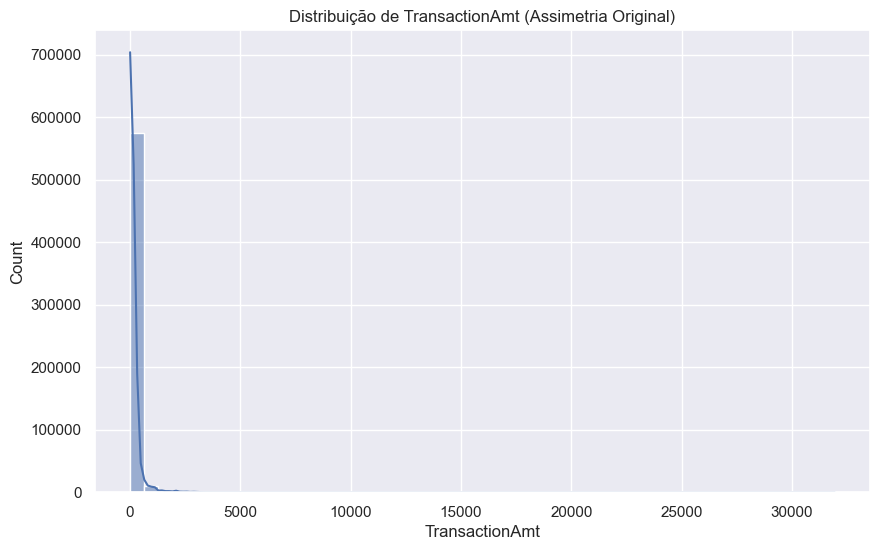

In [ ]:
# Gráfico com dados originais

# Define o estilo 
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='TransactionAmt', kde=True, bins=50)

plt.title('Distribuição de TransactionAmt (Assimetria Original)')
plt.show()

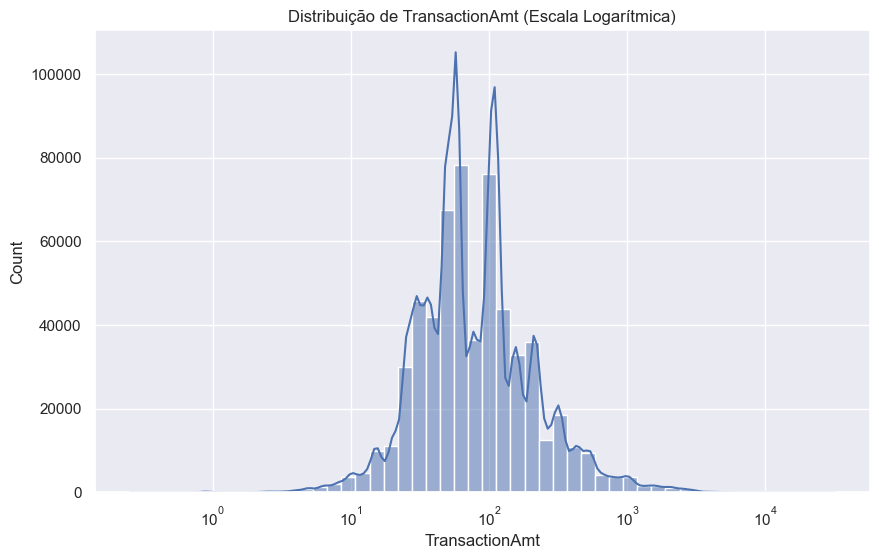

In [ ]:
# Gráfico em escala logarítmica

plt.figure(figsize=(10, 6))
# Usando log_scale=True para lidar com a alta assimetria
sns.histplot(data=df, x='TransactionAmt', kde=True, bins=50, log_scale=True)

plt.title('Distribuição de TransactionAmt (Escala Logarítmica)')
plt.show()

---
Transformação e Criação

In [78]:
def engineer_features(df):

    # --- Valor ---
    df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])

    # --- Tempo ---
    df["TransactionDay"] = df["TransactionDT"] / (60 * 60 * 24)
    df["TransactionWeekDay"] = (df["TransactionDay"] % 7).astype(int)

    # --- Comportamento agregado ---
    df["C_total"] = df[["C1","C2","C3","C4","C5"]].sum(axis=1)
    df["Amt_per_C1"] = df["TransactionAmt"] / (df["C1"] + 1)

    # --- Extremes ---
    threshold_99 = df["TransactionAmt"].quantile(0.99)
    df["Amt_extreme_99"] = (df["TransactionAmt"] > threshold_99).astype(int)

    return df

In [79]:
df = engineer_features(df)
df.shape

(590540, 48)

---
Agregações

obs.: em cenário real elas seriam calculadas apenas no treino

In [81]:
def add_card_aggregations(df):

    # Número de transações por cartão
    df["card1_tx_count"] = df.groupby("card1")["TransactionID"].transform("count")

    # Valor médio por cartão
    df["card1_amt_mean"] = df.groupby("card1")["TransactionAmt"].transform("mean")

    # Desvio padrão do valor por cartão
    df["card1_amt_std"] = df.groupby("card1")["TransactionAmt"].transform("std")

    # Razão entre valor atual e média histórica
    df["card1_amt_ratio"] = df["TransactionAmt"] / (df["card1_amt_mean"] + 1)

    return df

In [82]:
df = add_card_aggregations(df)
df.shape

(590540, 52)

---
Verificação de cartões em fraudes

obs.: Em contexto real, agregações por entidade (como cartão) devem ser calculadas apenas com base em dados históricos disponíveis até o momento da transação, evitando vazamento de informação futura.

In [87]:
df["card1"].nunique()

13553

In [88]:
df.groupby("card1")["TransactionID"].count().describe()

count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000
Name: TransactionID, dtype: float64

In [89]:
def add_card1_aggregations(df):

    # Volume de transações
    df["card1_tx_count"] = df.groupby("card1")["TransactionID"].transform("count")

    # Média do valor
    df["card1_amt_mean"] = df.groupby("card1")["TransactionAmt"].transform("mean")

    # Desvio padrão
    df["card1_amt_std"] = df.groupby("card1")["TransactionAmt"].transform("std")
    df["card1_amt_std"] = df["card1_amt_std"].fillna(0)

    # Razão valor atual / média histórica
    df["card1_amt_ratio"] = df["TransactionAmt"] / (df["card1_amt_mean"] + 1)

    return df

In [90]:
df = add_card1_aggregations(df)
df.shape

(590540, 54)

---
Verificação de domínio de email em fraudes

In [83]:
fraud_by_email = (
    df.groupby("P_emaildomain")["isFraud"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_by_email.head(10)

,count,mean
P_emaildomain,,
protonmail.com,76,0.407895
mail.com,559,0.189624
outlook.es,438,0.130137
aim.com,315,0.126984
outlook.com,5096,0.094584
hotmail.es,305,0.065574
live.com.mx,749,0.054740
hotmail.com,45250,0.052950
gmail.com,228355,0.043542


In [84]:
df["email_fraud_rate"] = df.groupby("P_emaildomain")["isFraud"].transform("mean")

---
Verificação de endereços por fraudes

In [85]:
fraud_by_addr = (
    df.groupby("addr1")["isFraud"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_by_addr.head(10)

,count,mean
addr1,,
305.0,9,0.666667
483.0,23,0.565217
466.0,2,0.500000
501.0,4,0.500000
471.0,2,0.500000
391.0,35,0.457143
431.0,38,0.342105
260.0,6,0.333333
432.0,38,0.289474


In [91]:
# taxa de fraude por addr1
df["addr_tx_count"] = df.groupby("addr1")["TransactionID"].transform("count")

# volume de transações por addr1
df["addr_fraud_rate"] = df.groupby("addr1")["isFraud"].transform("mean")

### Exploratory Risk Analysis

Antes da modelagem preditiva, foi conduzida uma análise exploratória orientada ao risco, com o objetivo de identificar diferenças estruturais entre transações fraudulentas e legítimas. A análise focou na distribuição dos valores monetários, no comportamento extremo, em padrões temporais e em desvios comportamentais relativos ao histórico do utilizador.

Essa etapa busca verificar se há sinal estatístico consistente nos dados e compreender como o risco se manifesta empiricamente antes da construção do modelo.

---
Fraudes têm comportamento monetário diferente?


isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

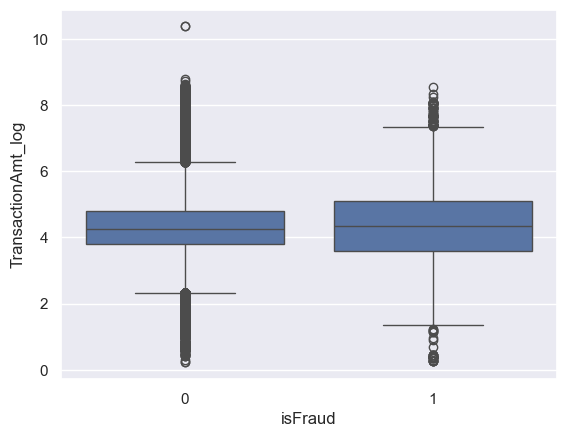

In [130]:
# Boxplot
sns.boxplot(data=df, x="isFraud", y="TransactionAmt_log")

# Medianas
df.groupby("isFraud")["TransactionAmt"].median()

A mediana da 'Fraude' mostra-se maior do que a mediana do 'Não-Fraude', o que indica, no geral, que as fraudes ocorrem em transações de maior valor. Ainda que possa ver visto no boxplot uma maior variação nos valores de transações fraudolentas.

Realizaremos um teste não paramétrico a fim de avaliar se essa diferença é estatisticamente significativa de fato. 

In [131]:
# teste de Mann-whitney U ( não paramétrico )
# dados assimétricos; presença de outliers; heterocedasticidade 

from scipy.stats import mannwhitneyu

fraud = df[df["isFraud"]==1]["TransactionAmt"]
non_fraud = df[df["isFraud"]==0]["TransactionAmt"]

stat, p = mannwhitneyu(fraud, non_fraud, alternative="two-sided")

print("--- Resultado do Teste Mann-Whitney U ---")
print(f"Estatística U: {stat:,.2f}")
print(f"p-value: {p:.10f}")

# interpretação 
alpha = 0.05
if p < alpha:
    print("\nConclusão: Rejeitamos H_0.")
    print("Há uma diferença estatisticamente significativa entre os valores das transações consideradas ou não fraudes.")
else:
    print("\nConclusão: Não rejeitamos H_0.")
    print("Não há evidências de que os valores das transações sejam diferentes estatisticamente.")

--- Resultado do Teste Mann-Whitney U ---
Estatística U: 5,858,540,820.50
p-value: 0.2259078350

Conclusão: Não rejeitamos H_0.
Não há evidências de que os valores das transações sejam diferentes estatisticamente.


O resultado do teste mostra que não é possível afirmar que o valor da transação ajude, isoladamente, a distinguir a 'Fraude' da 'Não-Fraude'. 

Este resultado pode ser devido a um comportamento e variação de valores muito semelhantes entre os dois grupos. E faz sentido ao se analisar a natureza do evento analisado: fraudadores buscam mimetizar o comportamento de compras normais dificultando a detecção.

---
Fraudes estão associadas a extremos?


In [132]:
df.groupby("Amt_extreme_99")["isFraud"].mean()



Amt_extreme_99
0    0.035095
1    0.024109
Name: isFraud, dtype: float64

In [133]:
df["isFraud"].mean().round(5)

np.float64(0.03499)

A média de 'Fraude' é superior nos dados completos do que no Top 1% valores de transições, o que isso significa? Que o risco de fraudes em transações de altíssimo valor é menor do que nas transações comuns.

O que pode ser explicado pelos sistemas de segurança bancários para transações de muito alto valor, que costumam disparar alertas automáticos e conduzir uma verificação imediata. E, novamente, pelo memitismo característico do evento analisado.

---
Existe padrão temporal? A fraude varia ao longo do tempo?


<Axes: xlabel='TransactionWeekDay'>

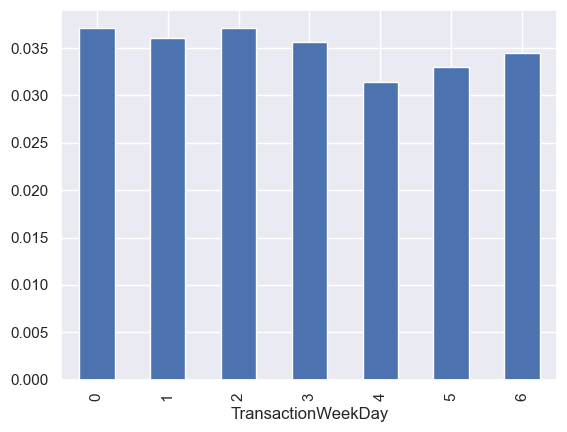

In [134]:
fraud_by_day = df.groupby("TransactionWeekDay")["isFraud"].mean()
fraud_by_day.plot(kind="bar")

Início e meio de semana possuem mais fraudes, enquanto dia 4 tem menor taxa de fraude.

É necessário investigar se é efeito da flutuação do volume de transações e se existe relação à hora do dia.

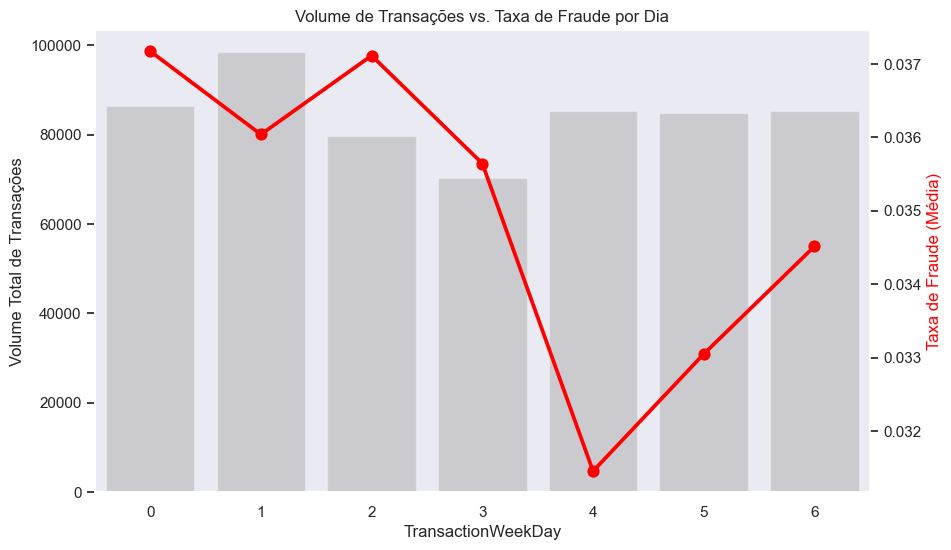

In [135]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# barra: volume total de transações por dia
sns.countplot(data=df, x='TransactionWeekDay', ax=ax1, alpha=0.3, color='gray')
ax1.grid(False) 
ax1.set_ylabel('Volume Total de Transações')

# linha: taxa de fraude (eixo secundário)
ax2 = ax1.twinx()
ax2.grid(False)
sns.pointplot(x=fraud_by_day.index, y=fraud_by_day.values, ax=ax2, color='red')
ax2.set_ylabel('Taxa de Fraude (Média)', color='red')

plt.title('Volume de Transações vs. Taxa de Fraude por Dia')
plt.show()

Quando avaliamos o volume de transações e comparamamos com a taxa de fraude para os dias da semana, vemos que existe uma queda drástica na taxa de fraude no dia 4 ( provavelmente quinta ou sexta ), com proporção perto de 0.031. Em contrapartida, dias 0, 1 e 2 concentram as maiores taxas de fraude, acima de 0.036, o que sugere ataques mais intensos no início da semana. 

Até aqui temos confirmação das suspeitas de que exista variação no comportamento de fraudes ao longo do tempo. Seguimos com um teste Qui-Quadrado para verificar se essa variação é estatisticamente significativa.

In [136]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['TransactionWeekDay'], df['isFraud'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"p-value do Teste Qui-Quadrado: {p_val:.10f}")
print("--- Resultado do Teste Qui-Quadrado ---")
print(f"Estatística X^2: {chi2:,.2f}")
print(f"p-value: {p_val:.10f}")

# interpretação 
alpha = 0.05
if p_val < alpha:
    print("\nConclusão: Rejeitamos H_0.")
    print("Há uma diferença estatisticamente significativa na proporção de fraudes entre os diferentes dias da semana.")
else:
    print("\nConclusão: Não rejeitamos H_0.")
    print("Não há evidências de que a proporção de fraudes entre os diferentes dias da semana seja diferente estatisticamente.")

p-value do Teste Qui-Quadrado: 0.0000000000
--- Resultado do Teste Qui-Quadrado ---
Estatística X^2: 68.70
p-value: 0.0000000000

Conclusão: Rejeitamos H_0.
Há uma diferença estatisticamente significativa na proporção de fraudes entre os diferentes dias da semana.


Os resultados do teste QQ indicam uma associação significativa entre o dia da semana e a ocorrência de fraude (p < 0.05), confirmando que o risco não é distribuído uniformemente ao longo do tempo.

Isso confirma nossas suspeitas, mas não nos informa o dia de maior risco. 

Seguimos com uma análise de associação para medir a força de efeito dessa diferença.

In [137]:
# Análise de Associação V de Cramér

n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"V de Cramer: {v_cramer:.4f}")

# interpretação 
if v_cramer < 0.1:
    print("\nAssociação fraca.")
elif v_cramer >=0.1 and v_cramer < 0.3:
    print("\nAssociação moderada.")
elif v_cramer >= 0.3 and v_cramer < 0.5:
    print("\nAssociação forte.")
else:
    print("\nAssociação muito forte.")
    

V de Cramer: 0.0108

Associação fraca.


A análise de associação por meio do V de Cramér indica associação estatisticamente significativa, porém fraca. Esse resultado sugere que, embora exista dependencia entre o dia de ocorrência e a fraude, seu efeito isolado é limitado. 

A análise dos resíduos, a seguir, permite identificar quais días contribuem de forma mais expressiva para a associação observada. 

In [138]:
# Análise dos Resíduos

# calcula a diferença entre observado e esperado
residuos = (contingency_table - expected) / np.sqrt(expected)

# focamos apenas na coluna de 'Fraude' (isFraud == 1)
residuos_fraude = residuos[1].sort_values(ascending=False)

df_risco = pd.DataFrame(residuos[1]).rename(columns={1: 'Resíduo'})

# interpretação
def classificar_risco(res):
    if res > 1.96: return "Risco Alto"
    elif res < -1.96: return "Risco Baixo"
    else: return "Risco Esperado"

df_risco['Classificação'] = df_risco['Resíduo'].apply(classificar_risco)

print("--- Tabela de Análise de Risco por Dia ---")
print(df_risco.sort_values(by='Resíduo', ascending=False))
print("-" * 40)

# dias com maior e menor risco
dias_altos = df_risco[df_risco['Resíduo'] > 1.96].index.tolist()
dias_baixos = df_risco[df_risco['Resíduo'] < -1.96].index.tolist()
dia_max = df_risco['Resíduo'].idxmax()
dia_min = df_risco['Resíduo'].idxmin()

print(f"Os dias com maior tendência de fraude são: {dias_altos} (Destaque para o Dia {dia_max})")
print(f"Os dias com menor tendência de fraude são: {dias_baixos} (Destaque para o Dia {dia_min})")




--- Tabela de Análise de Risco por Dia ---
                     Resíduo   Classificação
TransactionWeekDay                          
0                   3.431841      Risco Alto
2                   3.209071      Risco Alto
1                   1.761511  Risco Esperado
3                   0.925910  Risco Esperado
6                  -0.743043  Risco Esperado
5                  -3.022917     Risco Baixo
4                  -5.529112     Risco Baixo
----------------------------------------
Os dias com maior tendência de fraude são: [0, 2] (Destaque para o Dia 0)
Os dias com menor tendência de fraude são: [4, 5] (Destaque para o Dia 4)


A coluna 'Resíduo' representa o quanto a fraude real se desviou do esperado, tornado-se um ótimo indicador de risco esperado, resíduos positivos indicam frequência de fraude superior ao esperado, enquanto resíduos negativos indicam menor ocorrência do que o esperado. 

Assim conseguimos identificar os dias com maior tendência de fraude e os dias com menor tendência.

In [139]:
def analisar_risco_categoria(df, coluna_cat, coluna_target='isFraud'):
    # 1. Cálculos Base
    media_global = df[coluna_target].mean()
    stats = df.groupby(coluna_cat)[coluna_target].agg(['mean', 'count'])
    
    # 2. Cálculo de Risco Relativo e Diferença Percentual
    stats['Risco_Relativo'] = stats['mean'] / media_global
    stats['Diferenca_vs_Media_%'] = (stats['Risco_Relativo'] - 1) * 100
    
    # 3. Renomear para clareza
    stats = stats.rename(columns={'mean': 'Taxa_Fraude_%', 'count': 'Volume_Transacoes'})
    stats['Taxa_Fraude_%'] = stats['Taxa_Fraude_%'] * 100
    
    # Ordenar pelo maior risco
    stats = stats.sort_values(by='Diferenca_vs_Media_%', ascending=False)
    
    # 4. Sumário Executivo (Texto)
    dia_max = stats.index[0]
    risco_max = stats['Diferenca_vs_Media_%'].iloc[0]
    dia_min = stats.index[-1]
    risco_min = stats['Diferenca_vs_Media_%'].iloc[-1]
    
    print(f"ANÁLISE DE RISCO: {coluna_cat.upper()}")
    print(f"Taxa Média Global: {media_global*100:.2f}%")
    print(f"Alerta: O valor '{dia_max}' é o de maior risco ({risco_max:+.2f}% vs média).")
    print(f"Seguro: O valor '{dia_min}' é o de menor risco ({risco_min:+.2f}% vs média).")
        
    return stats

# Executando a função
df_relatorio = analisar_risco_categoria(df, 'TransactionWeekDay')


ANÁLISE DE RISCO: TRANSACTIONWEEKDAY
Taxa Média Global: 3.50%
Alerta: O valor '0' é o de maior risco (+6.24% vs média).
Seguro: O valor '4' é o de menor risco (-10.11% vs média).


Além da análise de associação, foi calculado o risco relativo de fraude por dia da semana, comparando a taxa observada em cada dia com a taxa média global. 

Observa-se variação moderada entre os dias, com alguns apresentando percentual de fraude superior à média. Contudo, as diferenças não são suficientemente expressivas para caracterizar forte determinismo temporal, sugerindo que o padrão semanal atua como fator complementar, e não decisivo, na modelagem do risco.

---
Desvios em relação ao histórico do cartão aumentam risco?


In [140]:
df.groupby("isFraud")["card1_amt_ratio"].median()

isFraud
0    0.624167
1    0.799955
Name: card1_amt_ratio, dtype: float64

A coluna "card1_amt_ratio" mede o quanto a transação atual se desvia da média histórica de determinado cartão, no caso o 'card1'. 

A mediana deste desvio é maior em transações de 'Fraude', 0.80, do que em transações de 'Não-Fraude', 0.62. Isso significa que, em transações fraudulentas, o valor está mais próximo ou acima do ticket médio do cartão do que em transações normais. 

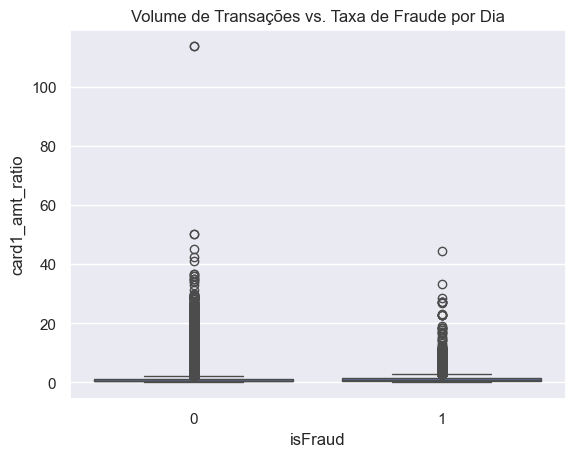

In [161]:
sns.boxplot(data=df, x="isFraud", y="card1_amt_ratio")
ax1.grid(False)
# ax2.set_ylabel('Taxa de Fraude (Média)', color='red')

plt.title('Volume de Transações vs. Taxa de Fraude por Dia')
plt.show()

In [142]:
# Teste Mann-Whitney U

# separação dos grupos
fraud_ratio = df[df["isFraud"]==1]["card1_amt_ratio"]
non_fraud_ratio = df[df["isFraud"]==0]["card1_amt_ratio"]

stat, p = mannwhitneyu(fraud_ratio, non_fraud_ratio, alternative="two-sided")

print("--- Teste Mann-Whitney: card1_amt_ratio ---")
print(f"Estatística U: {stat:,.2f}")
print(f"p-value: {p:.10f}")

# Interpretação
alpha = 0.05
if p < alpha:
    print("\nConclusão: Rejeitamos H_0.")
    print("Há uma diferença estatisticamente significativa em relação ao desvio em relação à média do cartão (ratio), o que é um forte indicador de fraude.")
else:
    print("\nConclusão: Não rejeitamos H_0.")
    print("Não há evidências de diferença significativa.")



--- Teste Mann-Whitney: card1_amt_ratio ---
Estatística U: 6,656,468,647.50
p-value: 0.0000000000

Conclusão: Rejeitamos H_0.
Há uma diferença estatisticamente significativa em relação ao desvio em relação à média do cartão (ratio), o que é um forte indicador de fraude.


Diferentemente da análise do valor bruto ('TransactionAmt'), a análise do desvio em relação ao histórico de gastos apresenta que há sim uma diferença significativa entre 'Fraude' e 'Não-Fraude'. 

Isto demonstra que a variável 'card1_amt_ratio' é uma forte canditada para a modelagem, contribuindo em compreender e detectar casos de fraude. 

De forma geral, este resultado também mostra que fraude é um fenômeno que se define mais pelos desvios, quebra de padrão, do que pelo valor bruto da transação ou preço do produto.

---
Perfis com maior taxa histórica apresentam maior incidência real?

In [ ]:
# Análise de Risco por Email
 
df["email_risk_bin"] = pd.qcut(df["email_fraud_rate"], q=4, duplicates="drop")

media_global = df["isFraud"].mean()
resumo_email = df.groupby("email_risk_bin")["isFraud"].agg(['mean', 'count']).rename(
    columns={'mean': 'Taxa_Real_%', 'count': 'Volume'}
)

# cálculo do risco relativo
resumo_email['Risco_Relativo'] = resumo_email['Taxa_Real_%'] / media_global
resumo_email['Taxa_Real_%'] = resumo_email['Taxa_Real_%'] * 100

print(f"--- Relatório de Risco: Histórico de E-mail ---")
print(f"Taxa Média da Base: {media_global*100:.2f}%\n")
print(resumo_email.sort_index())

# interpretação
risco_max = resumo_email['Risco_Relativo'].iloc[-1]
print(f"\nINTERPRETAÇÃO:")
print(f"O grupo de e-mails com maior risco histórico (último quartil) apresenta")
print(f"uma incidência de fraude {risco_max:.2f}x MAIOR que a média da base.")


--- Relatório de Risco: Histórico de E-mail ---
Taxa Média da Base: 3.50%

                  Taxa_Real_%  Volume  Risco_Relativo
email_risk_bin                                       
(-0.001, 0.0228]     2.074962  156533        0.593016
(0.0228, 0.0312]     2.795044  145758        0.798812
(0.0312, 0.0435]     4.318337  235461        1.234163
(0.0435, 0.408]      6.010836   52788        1.717872

INTERPRETAÇÃO:
O grupo de e-mails com maior risco histórico (último quartil) apresenta
uma incidência de fraude 1.72x MAIOR que a média da base.


A segmentação por quartis de risco histórico de e-mail evidencia padrão consistente: grupos com maior taxa histórica apresentam maior incidência observada de fraude no conjunto analisado. 

O quartil superior concentra risco relativo de aproximadamente 1,72 vezes a média global, indicando que o histórico agregado por domínio de e-mail captura sinal preditivo relevante. 

Ainda assim, o efeito é probabilístico e não determinístico, reforçando o papel da variável como componente complementar na modelagem.

In [147]:
# ALERTA: Risco Máximo ( Triangulação de risco )
cond_email = df["email_fraud_rate"] > 0.0435 # faixa 4 +
cond_dia = df["TransactionWeekDay"].isin([0, 1, 2]) # dias de alto risco
cond_ratio = df["card1_amt_ratio"] > 0.80 # desvio superior a 80%
alerta_maximo = df[cond_email & cond_dia & cond_ratio] # filtro combinado

# cálculo da taxa de fraude no grupo filtrado 
taxa_alerta = alerta_maximo["isFraud"].mean() * 100
vol_alerta = len(alerta_maximo)
lift_alerta = (taxa_alerta / (df["isFraud"].mean() * 100))


print(f"\nALERTA:")
print(f"Critérios: Email Crítico + Dia de Risco + Desvio de Hábito (> 0.80)")
print(f"Volume de Transações neste cenário: {vol_alerta}")
print(f"Taxa de Fraude Observada: {taxa_alerta:.2f}%")
print(f"Risco Relativo: Este cenário é {lift_alerta:.1f}x MAIS PERIGOSO que a média.")

if taxa_alerta > 15: # Exemplo de threshold para ação imediata
    print("\nCONCLUSÃO:")
    print(f"Transações que reúnem estes 3 fatores têm uma probabilidade de fraude de {taxa_alerta:.1f}%.")
    print("RECOMENDAÇÃO: Implementar bloqueio preventivo ou autenticação 2FA obrigatória para este perfil.")


ALERTA:
Critérios: Email Crítico + Dia de Risco + Desvio de Hábito (> 0.80)
Volume de Transações neste cenário: 52957
Taxa de Fraude Observada: 6.17%
Risco Relativo: Este cenário é 1.8x MAIS PERIGOSO que a média.


A combinação de múltiplos fatores de risco, como e-mail de alto risco, dia com risco relativo superior e desvio comportamental elevado, resulta em aumento adicional da taxa observada de fraude (6,17%), correspondente a aproximadamente 1,8 vezes a média da base. 

Esse resultado sugere que a interação entre sinais comportamentais e contextuais amplifica a probabilidade de fraude, evidenciando a importância de abordagens multivariadas em vez da análise isolada de variáveis.

Abaixo, avaliaremos o impacto financeiro dessa combinação.

In [ ]:
# Análise do impacto financeiro ( valor em dinheiro )

# criando a flag de alto risco
df['high_risk_flag'] = (cond_email & cond_dia & cond_ratio)

# calculando o prejuízo potencial (apenas as fraudes confirmadas dentro desse grupo)
prejuizo_alerta = df[(df['high_risk_flag'] == True) & (df['isFraud'] == 1)]['TransactionAmt'].sum()
prejuizo_total = df[df['isFraud'] == 1]['TransactionAmt'].sum()

percentual_prejuizo = (prejuizo_alerta / prejuizo_total) * 100

print(f"IMPACTO FINANCEIRO DO ALERTA")
print(f"Valor Total em Risco (fraudes nesse grupo): ${prejuizo_alerta:,.2f}")
print(f"Este alerta captura {percentual_prejuizo:.2f}% de TODO o prejuízo do dataset.")


IMPACTO FINANCEIRO DO ALERTA
Valor Total em Risco (Fraudes nesse grupo): $614,921.30
Este alerta captura 19.94% de TODO o prejuízo do dataset.


Do ponto de vista econômico, o cenário combinado captura cerca de 19,94% do prejuízo total do dataset, concentrando mais de 600 mil dólares em perdas associadas a fraude. 

Esse resultado demonstra que mesmo segmentos relativamente pequenos podem concentrar impacto financeiro relevante, reforçando a necessidade de priorização estratégica baseada em risco e não apenas em frequência absoluta.

### Model Selection and Validation

A análise exploratória confirmou a existência de distinções estatísticas relevantes entre transações fraudulentas e não fraudulentas, especialmente no que tange a padrões monetários e comportamentais. 

Observou-se que a fraude não se distribui de forma uniforme, concentrando-se em segmentos específicos onde a sobreposição de sinais de risco eleva exponencialmente a probabilidade de ocorrência. 

Contudo, a ausência de uma 'variável de corte' única, que separe as classes de forma linear, evidencia que o risco é multifatorial e não linear. 

A discriminação dos eventos fraudulentos depende da interação complexa entre múltiplos atributos, o que justifica a adoção de modelos de aprendizado supervisionado de alta capacidade. 

Com base nessas evidências, a etapa de modelagem preditiva foca na construção de um classificador robusto. O objetivo é mapear esses padrões combinados para otimizar o trade-off entre sensibilidade (recall) e a manutenção da fluidez operacional (redução de falsos positivos).


#### Initial Model Comparison

---
Regressão Logística ( sem balanceamento )

In [217]:
# Regressão logística ( sem balanceamento )

# target
y = df["isFraud"]

cols_to_drop = ["TransactionID", "isFraud", "TransactionAmt"]

X = df.drop(columns=cols_to_drop)
X.shape, y.shape

((590540, 55), (590540,))

In [218]:
# separar categóricas e numéricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_cols, categorical_cols

(['TransactionDT',
  'card1',
  'card2',
  'card3',
  'card5',
  'addr1',
  'addr2',
  'C1',
  'C2',
  'C3',
  'C4',
  'C5',
  'C6',
  'C7',
  'C8',
  'C9',
  'C10',
  'D1',
  'D2',
  'D3',
  'D4',
  'D5',
  'D2_missing',
  'D3_missing',
  'D4_missing',
  'D5_missing',
  'TransactionAmt_log',
  'TransactionDay',
  'TransactionWeekDay',
  'Amt_per_C1',
  'C_total',
  'Amt_extreme_99',
  'card1_tx_count',
  'card1_amt_mean',
  'card1_amt_std',
  'card1_amt_ratio',
  'email_fraud_rate',
  'addr_fraud_rate',
  'addr_tx_count'],
 ['ProductCD',
  'card4',
  'card6',
  'P_emaildomain',
  'M1',
  'M2',
  'M3',
  'M4',
  'M5',
  'M6',
  'M7',
  'M8',
  'M9',
  'is_high_risk_day',
  'email_risk_bin',
  'high_risk_flag'])

In [219]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

y_train.mean(), y_test.mean()

(np.float64(0.034989767234831076), np.float64(0.03499057359930459))

In [220]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# normalização e transformação
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# modelo baseline
log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

baseline_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg)
    ]
)

baseline_clf.fit(X_train, y_train)

c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [221]:
# avaliação

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = baseline_clf.predict(X_test)
y_prob = baseline_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

print("Accuracy:", (y_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_prob))

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

              precision    recall  f1-score   support

           0     0.9668    0.9993    0.9828    170963
           1     0.7455    0.0539    0.1005      6199

    accuracy                         0.9663    177162
   macro avg     0.8562    0.5266    0.5416    177162
weighted avg     0.9591    0.9663    0.9519    177162

Accuracy: 0.9662512276899109
ROC AUC: 0.8232549375745823


array([[170849,    114],
       [  5865,    334]])

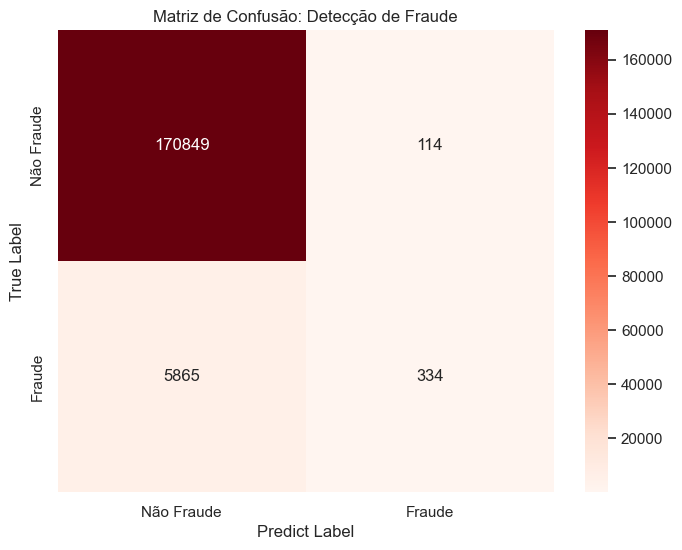

In [222]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Não Fraude', 'Fraude'], 
            yticklabels=['Não Fraude', 'Fraude'])

plt.xlabel('Predict Label')
plt.ylabel('True Label')
plt.title('Matriz de Confusão: Detecção de Fraude')
plt.show()

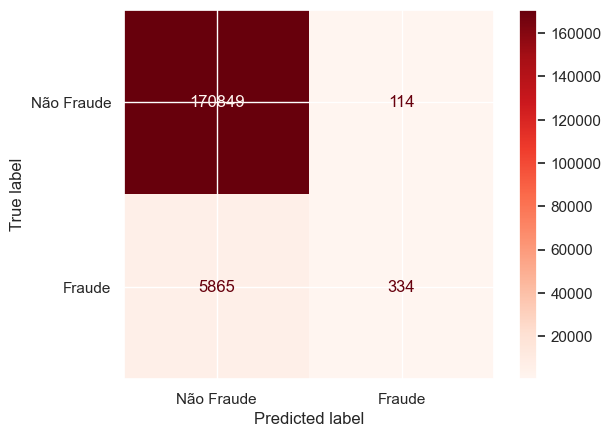

In [223]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Não Fraude', 'Fraude'])
disp.plot(cmap='Reds')
plt.show()


Text(0.5, 1.0, 'Curva ROC: Detecção de Fraude')

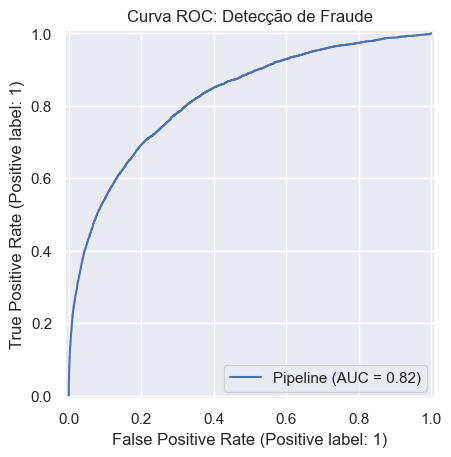

In [224]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(baseline_clf, X_test, y_test)
plt.title('Curva ROC: Detecção de Fraude')

A acurácia é alta porque a maioria dos dados é não fraude, mas percebemos que os resultados para a classe 1 ("Fraud") foram muito ruins: precisão baixa, recall e F1 baixíssimos. 

Apesar de a acurácia global parecer satisfatória, o modelo apresenta recall bastante baixo para a classe de fraudes, o que significa que muitas transações fraudulentas passam desapercebidas. Em contexto de risco financeiro, o custo de falsos negativos (não detectar fraude) é significativamente maior do que o custo de falso negativo (bloquear transação não fraude). 

Tais resultados devem-se ao forte desbalanceamento das classes, o que denota a necessidade de tratar explicitamente essa disparidade e ajustar o modelo para priorizar a detecção de fraudes.

Essa limitação é reforçada pela análise da curva ROC: embora a área sob a curva (AUC) indique que o modelo possui algum poder de separação entre as classes, o threshold (limiar) padrão de 0.5 mostra-se totalmente inadequado para capturar os eventos raros, exigindo uma calibração que favoreça a sensiblidade do modelo.

---
Regressão Logística ( com balanceamento )

In [225]:
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

balanced_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg_balanced)
    ]
)

balanced_clf.fit(X_train, y_train)

y_pred_bal = balanced_clf.predict(X_test)
y_prob_bal = balanced_clf.predict_proba(X_test)[:, 1]


c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [226]:
print(classification_report(y_test, y_pred_bal, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_bal))

conf_matrix = confusion_matrix(y_test, y_pred_bal)
conf_matrix

              precision    recall  f1-score   support

           0     0.9886    0.7422    0.8478    170963
           1     0.0971    0.7643    0.1722      6199

    accuracy                         0.7429    177162
   macro avg     0.5428    0.7532    0.5100    177162
weighted avg     0.9574    0.7429    0.8242    177162

ROC AUC: 0.828279526010066


array([[126881,  44082],
       [  1461,   4738]])

Com o balanceamento das classes, observamos uma melhora significativa na identificação de fraudes, elevando o recall para 76%. Embora a acurácia geral tenha reduzido e a precisão ainda permaneça baixa, o modelo agora é muito mais eficaz em não deixar os eventos de risco passarem desapercebidos.

Essa mudança evidencia o trade-off clássico: ao priorizar a detecção de falsos negativos (fraudes perdidas), aumentamos o número de falsos positivos (alarmes falsos). No entanto, o ROC (AUC) de 0.82 confirma que o modelo possui uma boa capacidade discriminatória entre as classes.



---
Regressão Logística com Random Under Sampler 

RandomUnderSampler é uma técnica de treinar modelos quando os dados são desbalanceados. Basicamente, ele identifica e remove parte de casos de não fraude, desta forma o modelo passa a ter quantidade equilibrada de casos nas classes (50/50). É uma técnica que reduz o tamanho do dataset, atua de forma rápida e estável, mas, em contrapartida, perde-se informação da classe 'majoritária'.

In [227]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression

undersample_pipeline = ImbPipeline(
    steps=[
        ("preprocess", preprocess),  
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=1000, n_jobs=-1))
    ]
)

undersample_pipeline.fit(X_train, y_train)

y_pred_under = undersample_pipeline.predict(X_test)
y_prob_under = undersample_pipeline.predict_proba(X_test)[:, 1]

c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [228]:
print(classification_report(y_test, y_pred_under, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_under))

conf_matrix = confusion_matrix(y_test, y_pred_under)
conf_matrix

              precision    recall  f1-score   support

           0     0.9887    0.7408    0.8470    170963
           1     0.0969    0.7674    0.1721      6199

    accuracy                         0.7418    177162
   macro avg     0.5428    0.7541    0.5096    177162
weighted avg     0.9575    0.7418    0.8234    177162

ROC AUC: 0.827834323932685


array([[126653,  44310],
       [  1442,   4757]])

O uso do Random Under Sampler reduziu o volume da classe majoritária, permitindo que a regressão logística fosse treinada em um cenário mais equilibrado e focado na classe de interesse.

Como esperado, houve um aumento expressivo do recall da classe de fraude (76%), em comparação ao modelo sem balanceamento, garantindo que a maioria das transações fraudulentas fosse capturada. O custo dessa sensibilidade foi a redução da precision e da acurácia global, elevando consideravelmente o volume de falsos positivos.

A área sob a curva ROC (AUC) de 0.82 indica que, embora o modelo tenha ganhado capacidade discriminatória em relação ao cenário inicial, o descarte de dados da classe legítima e o uso de um modelo linear limitam a precisão dos alertas.


---
Balanced Random Forest 

BalancedRandomForestClassifier é uma técnica de treinar modelos quando os dados são desbalanceados. Basicamente, em vez de usar todas os dados da classe 0 (não fraude) de uma vez, cada árvore recebe TODAS as fraudes, e uma pequena amostra sorteada das não fraudes. Cada árvore é treinada em um cenário balanceado (50/50) resultando em um bom entendimento dos dados em conjunto.



In [229]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

brf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),  
        ("model", brf)
    ]
)

brf_pipeline.fit(X_train, y_train)

y_pred_brf = brf_pipeline.predict(X_test)
y_prob_brf = brf_pipeline.predict_proba(X_test)[:, 1]



In [230]:
print(classification_report(y_test, y_pred_brf, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_brf))

conf_matrix = confusion_matrix(y_test, y_pred_brf)
conf_matrix

              precision    recall  f1-score   support

           0     0.9920    0.9460    0.9684    170963
           1     0.3463    0.7884    0.4812      6199

    accuracy                         0.9405    177162
   macro avg     0.6691    0.8672    0.7248    177162
weighted avg     0.9694    0.9405    0.9514    177162

ROC AUC: 0.9431950687675127


array([[161736,   9227],
       [  1312,   4887]])

O modelo Balanced Random Forest incorporou o balanceamento diretamente no processo de construção das árvores, permitindo lidar com a disparidade das classes de forma integrada.

Como resultado, observou-se uma evolução notável na precisão (0.34), mantendo simultaneamente um recall elevado (0.78). Diferente das abordagens anteriores, este modelo conseguiu reduzir drasticamente o volume de falsos positivos, sem comprometer a sensibilidade na identificação das fraudes.

A área sob a curva ROC (AUC) de 0.94 confirma uma excelente capacidade discriminatória. O modelo demonstra que consegue separar com alta confiança os eventos legítimos dos fraudulentos, capturando interações complexas entre as variáveis que são características desse tipo de risco.

---
Easy Ensemble

EasyEnsembleClassifier é uma técnica de treinar modelos quando os dados são desbalanceados. Basicamente, ele cria subconjuntos equilibrados dos dados, para cada subconjunto ele treina um modelo que aprende com seus próprios erros de forma iterativa (AdaBoost). É excelente em reduzir os falsos positivos pois combina vários modelos especialistas sem perda de informação.

In [231]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.ensemble import EasyEnsembleClassifier

# ajuste para o preprocess para ser leve
preprocess_leve = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

eec = EasyEnsembleClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=1
)

eec_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_leve),
        ("model", eec)
    ]
)

eec_pipeline.fit(X_train, y_train)

y_pred_eec = eec_pipeline.predict(X_test)
y_prob_eec = eec_pipeline.predict_proba(X_test)[:, 1]



In [232]:
print(classification_report(y_test, y_pred_eec, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_eec))

conf_matrix = confusion_matrix(y_test, y_pred_eec)
conf_matrix

              precision    recall  f1-score   support

           0     0.9856    0.7116    0.8265    170963
           1     0.0824    0.7141    0.1478      6199

    accuracy                         0.7117    177162
   macro avg     0.5340    0.7129    0.4871    177162
weighted avg     0.9540    0.7117    0.8028    177162

ROC AUC: 0.7858420982833381


array([[121665,  49298],
       [  1772,   4427]])

O modelo Easy Ensemble atingiu um recall de 0.71, indicando uma capacidade moderada de captura de fraudes, porém com um custo operacional elevado, refletido na baixa precisão (0.08).

Com um ROC (AUC) de 0.78, o modelo demonstra menor poder discriminatório, resultando em um volume crítico de falsos positivos (49.298 bloqueios indevidos). O diagnóstico confirma que a estratégia de subconjuntos equilibrados não foi suficiente para superar a complexidade do problema, mantendo um desequilíbrio acentuado entre a detecção e o impacto no cliente legítimo.


---
Avaliação e comparação dos modelos

In [193]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def evaluate_model(y_t, y_pd, y_pb):
    return{
        "Accuracy": accuracy_score(y_t, y_pd),
        "Precision_Fraud": precision_score(y_t, y_pd),
        "Recall_Fraud": recall_score(y_t, y_pd),
        "F1_Fraud": f1_score(y_t, y_pd),
        "ROC_AUC": roc_auc_score(y_t, y_pb)
    }

results = {}

results["Baseline_LogReg"] = evaluate_model(y_test, y_pred, y_prob)
results["ClassWeight_LogReg"] = evaluate_model(y_test, y_pred_bal, y_prob_bal)
results["UnderSample_LogReg"] = evaluate_model(y_test, y_pred_under, y_prob_under)
results["BalancedRF"] = evaluate_model(y_test, y_pred_brf, y_prob_brf)
results["EasyEnsemble"] = evaluate_model(y_test, y_pred_eec, y_prob_eec)

results_df = pd.DataFrame(results)
results_df

,Baseline_LogReg,ClassWeight_LogReg,UnderSample_LogReg,BalancedRF,EasyEnsemble
Accuracy,0.966088,0.746328,0.743935,0.940083,0.711733
Precision_Fraud,0.715576,0.098462,0.097868,0.343670,0.082401
Recall_Fraud,0.051137,0.766253,0.768834,0.783030,0.714147
F1_Fraud,0.095453,0.174501,0.173634,0.477685,0.147754
ROC_AUC,0.824961,0.830526,0.830186,0.942198,0.785842


A comparação detalhada entre os modelos revela nuances críticas para a estratégia de risco. 

O modelo logístico original apresenta uma acurácia enviesada, sendo incapaz de identificar a classe fraudulenta. 

Já as abordagens de UnderSampling e Logística com Balanceamento conseguiram elevar o recall, mas ao custo de uma precisão extremamente baixa (0.09), o que geraria um bloqueio massivo de transações legítimas e inviabilidade operacional.

O Balanced Random Forest destaca-se como a solução mais robusta, entregando um recall alto (0.78) com uma precisão significativamente superior (0.34) e excelente capacidade discriminatória (AUC 0.94). 

Em contrapartida, o EasyEnsemble não foi capaz de superar os benchmarks básicos, apresentando perda de performance em todas as métricas principais.

Sugestão Estratégica:
Recomenda-se o Balanced Random Forest como modelo produtivo por sua superioridade em capturar padrões complexos de fraude. Contudo, manteremos a Regressão Logística Ponderada como benchmark de controle, garantindo transparência e interpretabilidade, fatores essenciais para a governança e auditoria do processo de decisão.


#### Robust Validation

A comparação inicial entre os modelos foi realizada a partir de uma única divisão treino-teste. Embora informativa, essa abordagem pode introduzir variabilidade associada à forma como os dados foram particionados.

Para avaliar a estabilidade e a robustez dos modelos selecionados, aplica-se validação cruzada estratificada (Stratified K-Fold), preservando a proporção da classe fraudulenta em cada partição. O objetivo é verificar se o desempenho observado se mantém consistente em diferentes subconjuntos da base, reduzindo o risco de conclusões baseadas em um único split.

---
Stratified K-Fold

In [194]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(pipeline, X, y):
    
    aucs = []
    recalls = []
    f1s = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:, 1]
        
        aucs.append(roc_auc_score(y_val, y_proba))
        recalls.append(recall_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
    
    return {
        "AUC_mean": np.mean(aucs),
        "AUC_std": np.std(aucs),
        "Recall_mean": np.mean(recalls),
        "Recall_std": np.std(recalls),
        "F1_mean": np.mean(f1s),
        "F1_std": np.std(f1s),
    }

In [197]:
# criando subconjunto para a validação cruzada (sobrecarga na memória)
df_sample = df.sample(frac=0.2, random_state=42)
X_sample = df_sample.drop("isFraud", axis=1)
y_sample = df_sample["isFraud"]

# Rode a função no sample
log_cv_results = cross_validate_model(balanced_clf, X_sample, y_sample)
brf_cv_results = cross_validate_model(brf_pipeline, X_sample, y_sample)

cv_results_df = pd.DataFrame({
    "Logistic_ClassWeight": log_cv_results,
    "BalancedRF": brf_cv_results
})

cv_results_df

c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\karen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n

,Logistic_ClassWeight,BalancedRF
AUC_mean,0.831374,0.910262
AUC_std,0.008622,0.003859
Recall_mean,0.764263,0.720882
Recall_std,0.014065,0.014716
F1_mean,0.179047,0.381986
F1_std,0.002377,0.008921


A validação cruzada estratificada reforça o desempenho consistente do Balanced Random Forest, que apresenta maior capacidade discriminativa (AUC superior), melhor equilíbrio entre recall e precision e estabilidade nas métricas ao longo das partições. Esses resultados indicam que o modelo não apenas performa melhor em um único split, mas mantém robustez em diferentes amostras da base.

A regressão logística com balanceamento permanece como benchmark interpretável, útil para comparação e compreensão dos efeitos das variáveis, embora apresente limitações na captura de relações não lineares.

Decisão: Com base nas evidências de validação, o Balanced Random Forest é adotado como modelo principal para as etapas subsequentes de avaliação probabilística e otimização de decisão.

### Probability Calibration

A validação anterior concentrou-se na capacidade discriminativa do modelo, ou seja, na sua habilidade de ordenar transações por nível de risco. Contudo, em aplicações reais, não basta separar fraude de não fraude: é igualmente importante avaliar se as probabilidades estimadas refletem adequadamente a frequência observada dos eventos.

Assim, procede-se à análise de calibração probabilística do modelo selecionado, examinando a qualidade das probabilidades previstas antes da definição do limiar de decisão.

---
Brier Score

O Brier Score mede o erro quadrático médio entre as probabilidades previstas pelo modelo e os resultados observados (0 ou 1). 

Valores menores indicam melhor calibração, ou seja, maior alinhamento entre risco estimado e frequência real do evento. Diferentemente da AUC, que avalia capacidade de separação, o Brier Score avalia qualidade probabilística.

In [210]:
# probabilidades no conjunto de teste
y_prob_brf = brf_pipeline.predict_proba(X_test)[:, 1]
y_pred_brf = brf_pipeline.predict(X_test)

# brier score (erro quadrado das probabilidades)
from sklearn.metrics import brier_score_loss

def interpretar_brier(y_test, y_prob):
    score = brier_score_loss(y_test, y_prob)

    baseline = brier_score_loss(y_test, [y_test.mean()] * len(y_test))

    status = "BEM CALIBRADO" if score < baseline else "MAL CALIBRADO"
    melhoria = (1 - (score / baseline)) * 100

    print(f"--- Relatório de Calibração (Brier Score) ---")
    print(f"Brier Score Atual: {score:.4f}")
    print(f"Brier Baseline:    {baseline:.4f}")
    print(f"Status: {status}")
    
    if score < baseline:
        print(f"Desempenho: O modelo supera o baseline em {melhoria:.1f}% na estimativa de probabilidades.")
    else:
        print("Nota: O modelo apresenta desalinhamento nas probabilidades brutas (calibração).")


interpretar_brier(y_test, y_prob_brf)





--- Relatório de Calibração (Brier Score) ---
Brier Score Atual: 0.0812
Brier Baseline:    0.0338
Status: MAL CALIBRADO
Nota: O modelo apresenta desalinhamento nas probabilidades brutas (calibração).


O Brier Score obtido indica desalinhamento nas probabilidades previstas pelo modelo. O valor inferior observado no baseline decorre do forte desbalanceamento da base, onde prever consistentemente a classe majoritária reduz artificialmente o erro quadrático médio. 

Assim, embora o modelo apresente excelente capacidade discriminativa (AUC elevada), suas probabilidades brutas não devem ser interpretadas diretamente como estimativa precisa de risco absoluto.

---
Calibration Curve

A curva de calibração compara as probabilidades previstas pelo modelo com as frequências reais observadas em cada intervalo de risco. 

Um modelo perfeitamente calibrado apresentaria pontos alinhados à diagonal, indicando que a probabilidade estimada corresponde à proporção real de eventos.

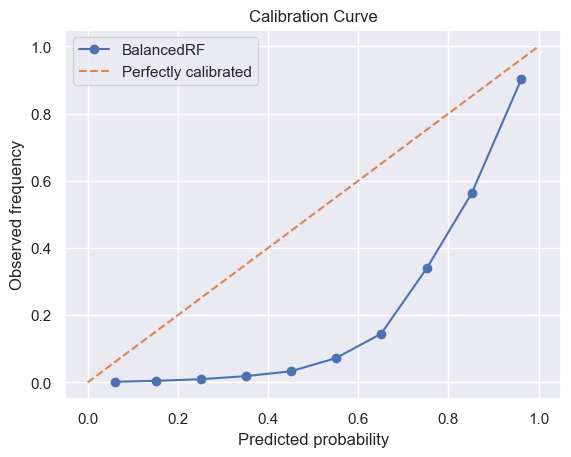

In [203]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob_brf, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label='BalancedRF')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

A curva de calibração indica que o Balanced Random Forest não apresenta alinhamento perfeito entre as probabilidades previstas e as frequências observadas. Observa-se tendência de superestimação da probabilidade absoluta de fraude em determinados intervalos, evidenciada pelo desvio sistemático em relação à linha diagonal ideal.

Esse comportamento não compromete a utilidade do modelo. Em contextos de detecção de fraude, a principal função do classificador é ordenar adequadamente as transações por nível de risco (capacidade discriminativa), e não necessariamente fornecer estimativas probabilísticas perfeitamente calibradas. Essa capacidade de separação é corroborada pelo elevado AUC (~0.91).

O desalinhamento probabilístico indica, contudo, que o threshold padrão de 0.5 pode não ser o ponto ótimo de decisão. Assim, em vez de descartar o modelo, procede-se à otimização do limiar de decisão, buscando equilibrar recall e precision de acordo com o trade-off operacional desejado.

### Decision Optimization

Após avaliar a capacidade discriminativa e a calibração probabilística do modelo, procede-se à definição do limiar de decisão mais adequado ao contexto de risco. 

Nesta etapa, o foco desloca-se da qualidade estatística do modelo para o trade-off operacional entre detecção de fraude e impacto de falsos positivos.

---
Precision-Recall Analysis

A curva Precision-Recall avalia o desempenho do modelo sob diferentes thresholds, evidenciando o trade-off entre sensibilidade (recall) e precisão. 

Em cenários de forte desbalanceamento, essa métrica é particularmente relevante, pois destaca o comportamento do modelo na classe minoritária (fraude), permitindo identificar regiões onde ganhos de recall implicam aumentos substanciais de falsos positivos.

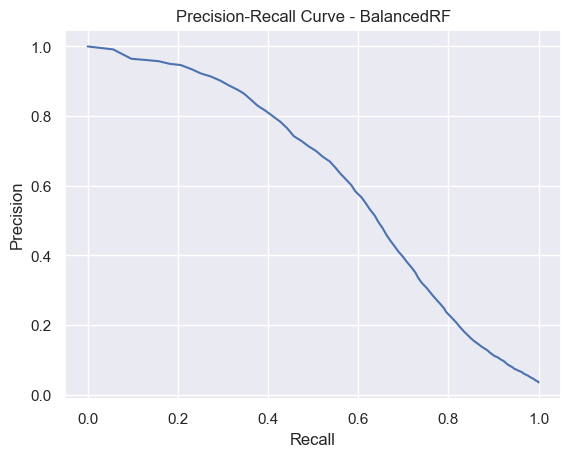

In [211]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_brf)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - BalancedRF")
plt.show()

A curva Precision–Recall evidencia o trade-off estrutural do modelo: à medida que o recall aumenta (maior capacidade de capturar fraudes), observa-se queda progressiva na precision, indicando aumento de falsos positivos.

Nota-se que o modelo mantém níveis elevados de precisão em regiões de recall moderado, mas passa a perder eficiência à medida que se aproxima da captura quase total das fraudes. Esse comportamento é esperado em cenários de evento raro, onde maximizar sensibilidade implica aumento significativo de alertas incorretos.

Assim, a definição do threshold ideal depende do equilíbrio desejado entre detecção de fraude e impacto operacional, sendo inadequado assumir automaticamente o ponto de corte padrão de 0.5.

---
Threshold Comparison

Para avaliar o impacto operacional da escolha do limiar de decisão, foram testados diferentes thresholds, analisando suas implicações sobre accuracy, precision, recall e F1-score.

In [212]:
# threshold maximiza F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

best_f1_threshold

np.float64(0.75)

In [ ]:
# threshold prioriza recall

recall_target = 0.85

valid_indices = np.where(recall >= recall_target)[0]
if len(valid_indices) > 0:
    threshold_recall_target = thresholds[valid_indices[-1]]
else:
    threshold_recall_target = None

threshold_recall_target

np.float64(0.39)

In [216]:
# avaliar métricas

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_threshold(y_true, y_prob, threshold):
    y_pred_thresh = (y_prob >= threshold).astype(int)
    
    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred_thresh),
        "Precision": precision_score(y_true, y_pred_thresh),
        "Recall": recall_score(y_true, y_pred_thresh),
        "F1": f1_score(y_true, y_pred_thresh),
    }

results_threshold = pd.DataFrame([
    evaluate_threshold(y_test, y_prob_brf, 0.5),
    evaluate_threshold(y_test, y_prob_brf, best_f1_threshold),
    evaluate_threshold(y_test, y_prob_brf, threshold_recall_target)
])

results_threshold

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.914146,0.259283,0.782868,0.389549
1,0.75,0.973979,0.652174,0.549282,0.596322
2,0.39,0.834778,0.157258,0.853847,0.265600


O threshold de 0.50 representa o ponto padrão de decisão e privilegia recall elevado (≈ 78%), capturando a maior parte das fraudes, porém com precision moderada (≈ 26%), implicando volume considerável de falsos positivos.

O threshold de 0.75 apresenta maior equilíbrio entre precisão (≈ 65%) e recall (≈ 55%), resultando no maior F1-score (≈ 0.60). Esse ponto reduz bloqueios indevidos e mantém capacidade relevante de detecção.

Já o threshold de 0.39 maximiza o recall (≈ 85%), porém com forte queda na precision (≈ 16%), caracterizando cenário de bloqueio agressivo e elevado custo operacional.

A comparação evidencia o trade-off estrutural da decisão: reduzir o threshold aumenta sensibilidade, mas amplia falsos positivos; elevá-lo melhora a precisão, mas permite maior evasão de fraude.

No cenário analisado, o threshold de 0.75 apresenta o melhor compromisso entre proteção financeira e sustentabilidade operacional, sendo adotado como ponto de decisão recomendado para este contexto.

### Conclusion

A detecção de fraude financeira constitui um problema clássico de evento raro, no qual a classe fraudulenta representa pequena fração das transações. Nesse contexto, métricas tradicionais como acurácia tornam-se insuficientes, exigindo análise focada em recall, precision, F1-score e AUC.

A análise exploratória confirmou a presença de sinal preditivo relevante nos dados, evidenciado por diferenças estatisticamente significativas no comportamento monetário, ocorrência de valores extremos e padrões comportamentais associados ao histórico do cartão. Esses achados justificaram a aplicação de modelos supervisionados.

Entre os modelos avaliados, o Balanced Random Forest apresentou maior capacidade discriminativa (AUC ≈ 0.91) e melhor equilíbrio entre recall e precision em comparação à regressão logística ponderada. A validação cruzada estratificada demonstrou estabilidade consistente, reforçando a robustez do modelo.

Embora a calibração probabilística tenha indicado desalinhamento nas probabilidades absolutas, tal comportamento não compromete a ordenação de risco. A análise de threshold evidenciou o trade-off central da gestão de fraude: maior sensibilidade implica aumento de falsos positivos, enquanto maior precisão reduz bloqueios indevidos ao custo de maior evasão de fraude.

No cenário analisado, o threshold de 0.75 apresentou o melhor compromisso operacional, maximizando o F1-score e oferecendo equilíbrio sustentável entre proteção financeira e experiência do cliente.

Em ambiente real, a decisão final deveria incorporar matriz explícita de custos e possivelmente integrar o modelo a arquitetura multicamada (como revisão manual para casos intermediários). 

Em síntese, os resultados indicam que a eficácia de um modelo de detecção de fraude depende não apenas da escolha do algoritmo, mas da adequação das métricas ao contexto de evento raro, da validação estatística consistente e da definição criteriosa do limiar de decisão. 

A performance observada reforça que a modelagem de risco é, fundamentalmente, um problema de otimização sob restrições operacionais, no qual discriminação, calibração e custo devem ser avaliados de forma integrada.
